## Synthetic dataset demonstration

In [1]:
# required modules (under Anaconda use: > conda install -c conda-forge <package>)
if False: # (skip if already installed)
    !pip install lark-parser
    !pip install linear-tree
    !pip install pydot
    !pip install pydotplus
    !pip install hopsy
    !pip install janus-swi
    # download and install SWI Prolog from https://www.swi-prolog.org/download/stable

In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

# standard imports
import os
import sys
import random
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_text
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Using janus - set SWI Prolog home
SWI_HOME = r"C:\Program Files\swipl"
os.environ["SWI_HOME_DIR"] = SWI_HOME
os.add_dll_directory(os.path.join(SWI_HOME, "bin"))

# local imports
sys.path.append('../src/') # local path
import reasonx
import dautils

# for reproducibility
random.seed(42)
np.random.seed(0)

# set to False to remove assertion check
assertion_check = True

# Folder for saving plots
plots = 'plots/'

In [3]:
# create a toy dataset with two classes and two features
# based on (independent) Gaussian distributions

mu_x1, sigma_x1 = 0.1, 0.15 # mean and standard deviation
mu_y1, sigma_y1 = 0.8, 0.3
x = np.random.normal(mu_x1, sigma_x1, 500)
y = np.random.normal(mu_y1, sigma_y1, 500)

mu_x2, sigma_x2 = 1.25, 0.1 # mean and standard deviation
mu_y2, sigma_y2 = 0.5, 0.3
x_ = np.random.normal(mu_x2, sigma_x2, 500)
y_ = np.random.normal(mu_y2, sigma_y2, 500)

class_1x = np.concatenate((x, x_), axis = 0)
class_1y = np.concatenate((y, y_), axis = 0)

mu_x1, sigma_x1 = 0.4, 0.2 # mean and standard deviation
mu_y1, sigma_y1 = -0.4, 0.05
x = np.random.normal(mu_x1, sigma_x1, 500)
y = np.random.normal(mu_y1, sigma_y1, 500)

mu_x2, sigma_x2 = 0.7, 0.08 # mean and standard deviation
mu_y2, sigma_y2 = 0.6, 0.4
x_ = np.random.normal(mu_x2, sigma_x2, 500)
y_ = np.random.normal(mu_y2, sigma_y2, 500)

class_2x = np.concatenate((x, x_), axis = 0)
class_2y = np.concatenate((y, y_), axis = 0)

class_all  = ['class 0']*1000+['class 1']*1000

x_all = ((np.concatenate((class_1x, class_2x), axis = 0)) * 1000)
y_all = ((np.concatenate((class_1y, class_2y), axis = 0)) * 1000)

df = pd.DataFrame(x_all, columns=['feature1'])
df["feature2"] = y_all
df["class"] = class_all

df = df.astype({'feature1': 'int32', 'feature2': 'int32'})
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   feature1  2000 non-null   int32
 1   feature2  2000 non-null   int32
 2   class     2000 non-null   str  
dtypes: int32(2), str(1)
memory usage: 31.4 KB


In [4]:
continuous_atts = ['feature1', 'feature2']
nominal_atts = []
ordinal_atts = []
# class attribute
target = 'class'
# predictive atts
pred_atts = nominal_atts + ordinal_atts + continuous_atts

decode = {
    'class': {
        0: 'class 0', 1: 'class 1'
    }
}

prefix_sep = "_" # separator for one-hot encoding
df_code = dautils.Encode(nominal=nominal_atts, ordinal=ordinal_atts+[target], decode=decode)
df_encoded_onehot = df_code.fit_transform(df)
df_encoded_onehot.head()

,feature1,feature2,class
0,364,914,0
1,160,789,0
2,246,1128,0
3,436,729,0
4,380,695,0


In [5]:
import matplotlib.pyplot as plt

# general settings  
plt.style.use("seaborn-v0_8-whitegrid")
plt.rc('font', size=14)
plt.rc('legend', fontsize=14)
plt.rc('lines', linewidth=2)
plt.rc('axes', linewidth=2)
plt.rc('axes', edgecolor='k')
plt.rc('xtick.major', width=2)
plt.rc('xtick.major', size=6)
plt.rc('ytick.major', width=2)
plt.rc('ytick.major', size=6)
plt.rc('pdf', fonttype=42)
plt.rc('ps', fonttype=42)

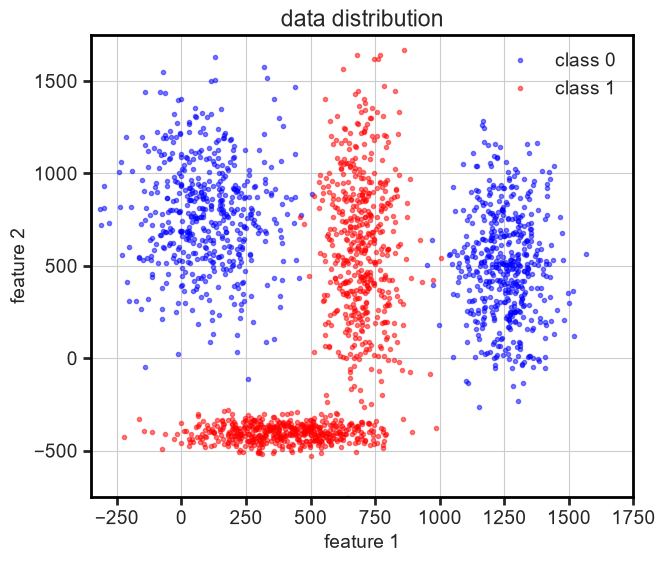

In [6]:
plt.figure(figsize=(7, 6))
x_min, x_max, y_min, y_max = -350, 1750, -750, 1750

groups = df.groupby('class')
colours = ["blue", "red"]
colour_index = 0

for name, group in groups:
    plt.plot(group.feature1, group.feature2, marker='o', linestyle='', markersize=3, label=name, alpha=0.5, color = colours[colour_index])
    colour_index=+1

plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.title("data distribution")
plt.legend()
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

plt.show()

In [7]:
# encoded atts names
encoded_pred_atts = df_code.encoded_atts(pred_atts)
# split dataset
X, y = df_encoded_onehot[encoded_pred_atts], df_encoded_onehot[target]
X1, _, y1, _ = train_test_split(X, y, test_size=0.3, random_state=42)
# train a decision tree
clf1 = DecisionTreeClassifier(max_depth=3, min_impurity_decrease=0.001)
clf1.fit(X1, y1)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.001
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term

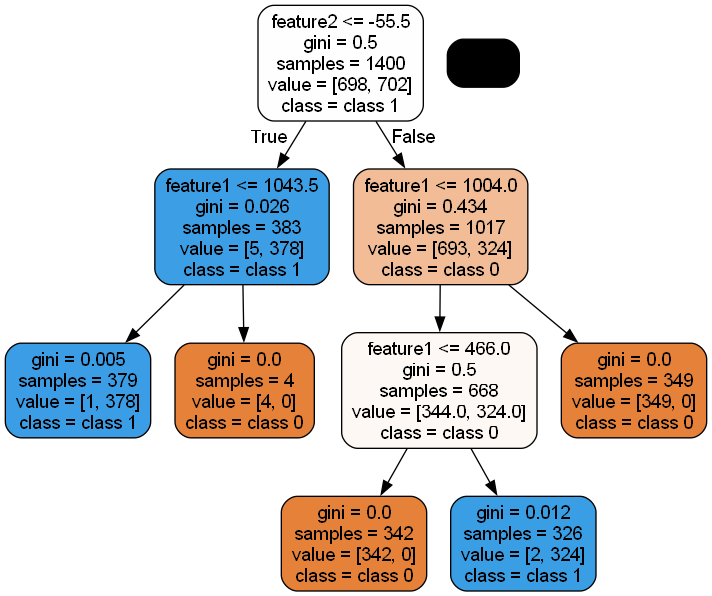

In [8]:
from sklearn import tree
import pydotplus
from IPython.display import Image

# visualize the decision tree
dot_data = tree.export_graphviz(clf1, out_file=None, 
                                feature_names=encoded_pred_atts, # attributes names
                                class_names=[v for _, v in sorted(df_code.decode[target].items())], # class labels
                                filled=True, rounded=True)  
graph = pydotplus.graph_from_dot_data(dot_data)  
Image(graph.create_png())

In [9]:
# visualize the decision tree in textual form
rules = export_text(clf1, feature_names=["feature1", "feature2"])
print(rules)

|--- feature2 <= -55.50
|   |--- feature1 <= 1043.50
|   |   |--- class: 1
|   |--- feature1 >  1043.50
|   |   |--- class: 0
|--- feature2 >  -55.50
|   |--- feature1 <= 1004.00
|   |   |--- feature1 <= 466.00
|   |   |   |--- class: 0
|   |   |--- feature1 >  466.00
|   |   |   |--- class: 1
|   |--- feature1 >  1004.00
|   |   |--- class: 0



In [10]:
# instance to explain
x_f1, x_f2 = 1100, 661
# predicted class
x_class = clf1.predict([[x_f1, x_f2]])[0]

D:\Prog\anaconda3\envs\poc_cf\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


D:\Prog\anaconda3\envs\poc_cf\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


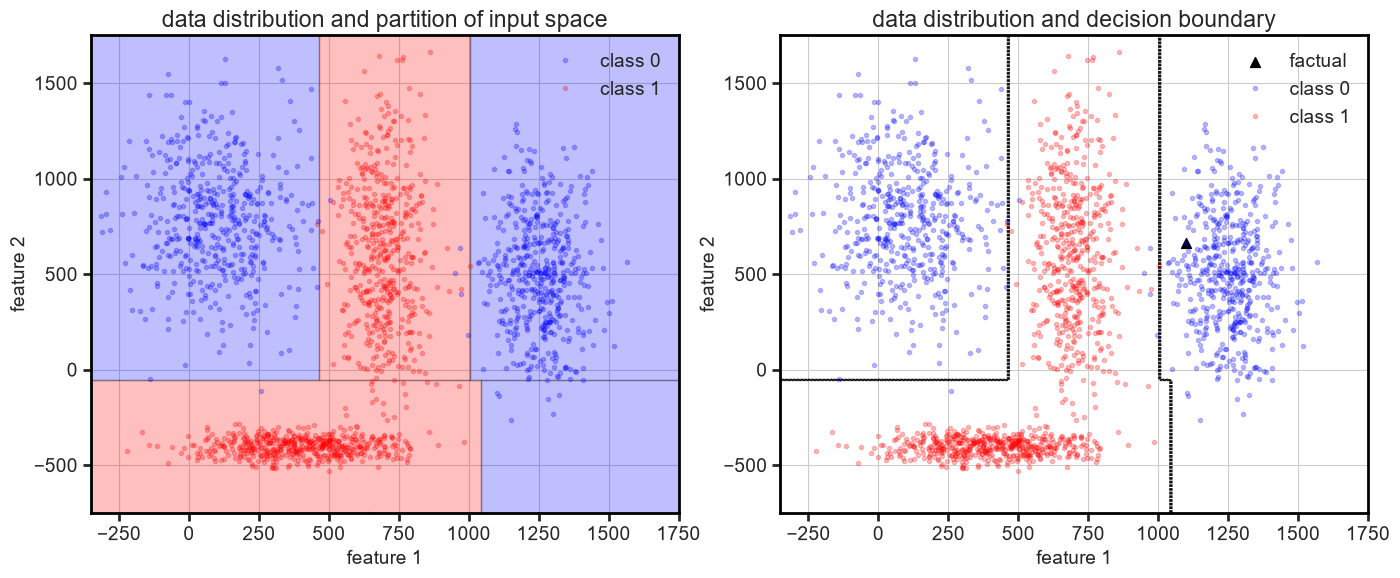

In [11]:
plt.figure(figsize=(14, 6))

xx, yy = np.meshgrid(np.arange(x_min, x_max + 50, 10), np.arange(y_min, y_max + 50, 10))

Z = clf1.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
# https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.contourf.html

# VERSION 1

plt.subplot(1, 2, 1)
#plt.contourf(xx, yy, Z, alpha=0.25, cmap=plt.cm.Greens)
#plt.contourf(xx, yy, Z, alpha=0.5, cmap=plt.cm.coolwarm)
plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.title("data distribution and partition of input space")

colour_index = 0
for name, group in groups:
    plt.plot(group.feature1, group.feature2, marker='o', linestyle='', markersize=3, label=name, alpha=0.25, color = colours[colour_index])
    colour_index=+1

# PLOT ALL PARTIOTIONS
rect = plt.Rectangle((x_min, y_min), abs(1043.5 - x_min), abs(-55.5 - y_min), fill = True, alpha = 0.25, facecolor = "r", edgecolor = "k", linestyle = "-", linewidth = 1)
plt.gca().add_patch(rect)
rect = plt.Rectangle((1043.5, y_min), abs(x_max + 50 - 1043.5), abs(-55.5 - y_min), fill = True, alpha = 0.25, facecolor = "b", edgecolor = "k", linestyle = "-",linewidth = 1)
plt.gca().add_patch(rect)
rect = plt.Rectangle((x_min, -55.5), abs(466 - x_min), abs(y_max + 50 - (-55.5)), fill = True, alpha = 0.25, facecolor = "b", edgecolor = "k", linestyle = "-", linewidth = 1)
plt.gca().add_patch(rect)
rect = plt.Rectangle((466, -55.5), abs(1004 - 466), abs(y_max + 50 - (-55.5)), fill = True, alpha = 0.25, facecolor = "r", edgecolor = "k", linestyle = "-",linewidth = 1)
plt.gca().add_patch(rect)
rect = plt.Rectangle((1004, -55.5), abs(x_max + 50 - 1004), abs(y_max + 50 - (-55.5)), fill = True, alpha = 0.25, facecolor = "b", edgecolor = "k", linestyle = "-",linewidth = 1)
plt.gca().add_patch(rect)

plt.legend()

# VERSION 2

plt.subplot(1, 2, 2)

plt.contour(xx, yy, Z, linewidths=0.5, linestyles = "dashed", colors = "black")
plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.title("data distribution and decision boundary")

plt.scatter(x_f1, x_f2, c="black", marker="^", zorder=1, s = 50, label = "factual", rasterized=True)

colour_index = 0
for name, group in groups:
    plt.plot(group.feature1, group.feature2, marker='o', linestyle='', markersize=3, label=name, alpha=0.25, color = colours[colour_index])
    colour_index=+1

plt.legend()
plt.tight_layout()

plt.show()

In [12]:
# initialise ReasonX
r = reasonx.ReasonX(pred_atts, target, df_code, verbose=2)
r.model(clf1)

In [13]:
# instance to explain
print("features:", x_f1, x_f2)
print("class:", x_class)

features: 1100 661
class: 0


In [14]:
# factual rule on an instance
# r.instance("F", features=X1.iloc[0:1], label=y1.iloc[0])
# or
# r.instance("F", features={'feature1':1100, 'feature2':661}, label=0)
# or
r.instance("F", features=[x_f1, x_f2], label=x_class)
r.solveopt()

---
Answer constraint: F.feature1=1100.0,F.feature2=661.0
Rule satisfied by F: IF F.feature1>1004.0,F.feature2> -55.5 THEN class 0 [1.0000, 0.2493]


D:\Prog\anaconda3\envs\poc_cf\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


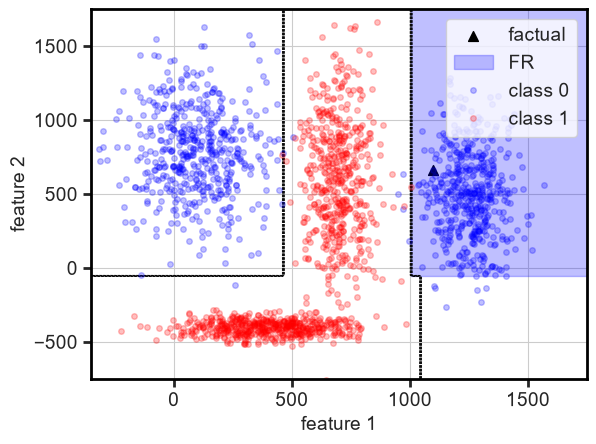

In [15]:
# DISPLAY THE RULE

# CASES
# 1) upper bounded by a > delta = abs(x_min - a) > (x_min), delta
# 2) lower bounded by a > delta = abs(x_max - a) > (a), delta
# 3) upper bounded by b, lower bounded by a > delta = abs(b - a) > (a), delta

#https://scikit-learn.org/0.24/auto_examples/tree/plot_iris_dtc.html
xx, yy = np.meshgrid(np.arange(x_min, x_max + 50, 10), np.arange(y_min, y_max + 50, 10))

Z = clf1.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.contour(xx, yy, Z, linewidths=0.5, linestyles="--", colors = "black")

plt.xlabel("feature 1")
plt.ylabel("feature 2")

plt.scatter(x_f1, x_f2, c="black", marker="^", zorder=1, s = 50, label = "factual", rasterized=True)

# manual translation into lines or squares
# Rule satisfied by F: IF F.feature1>1004.0,F.feature2> -55.5 THEN class0 [1.0000]

# CASE 2)
delta_x = abs(x_max - 1004)
x = 1004
# CASE 2)
delta_y = abs(y_max - (-55.5))
y = -55.5

rect = plt.Rectangle((x, y), delta_x, delta_y, fill = True, alpha = 0.25, color = "blue", label = "FR")
plt.gca().add_patch(rect)

colour_index = 0
for name, group in groups:
    plt.plot(group.feature1, group.feature2, marker='o', linestyle='', markersize=4, label=name, alpha=0.25, color = colours[colour_index], rasterized=True)
    colour_index=+1

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.legend(frameon=True)
#plt.title("factual region (rule)")

plt.savefig(plots+"factual_region.pdf", bbox_inches='tight', dpi=400)
plt.show()

In [16]:
# contrastive instance with min confidence
r.instance("CE", label=1-x_class, minconf=0.8)
r.solveopt()

---
Answer constraint: F.feature1=1100.0,F.feature2=661.0,CE.feature2<= -55.5,CE.feature1<=1043.5
Rule satisfied by F: IF F.feature2> -55.5,F.feature1>1004.0 THEN class 0 [1.0000, 0.2493]
Rule satisfied by CE: IF CE.feature2<= -55.5,CE.feature1<=1043.5 THEN class 1 [0.9974, 0.2707]
---
Answer constraint: F.feature1=1100.0,F.feature2=661.0,CE.feature2> -55.5,CE.feature1>466.0,CE.feature1<=1004.0
Rule satisfied by F: IF F.feature2> -55.5,F.feature1>1004.0 THEN class 0 [1.0000, 0.2493]
Rule satisfied by CE: IF CE.feature2> -55.5,CE.feature1>466.0,CE.feature1<=1004.0 THEN class 1 [0.9939, 0.2329]


D:\Prog\anaconda3\envs\poc_cf\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


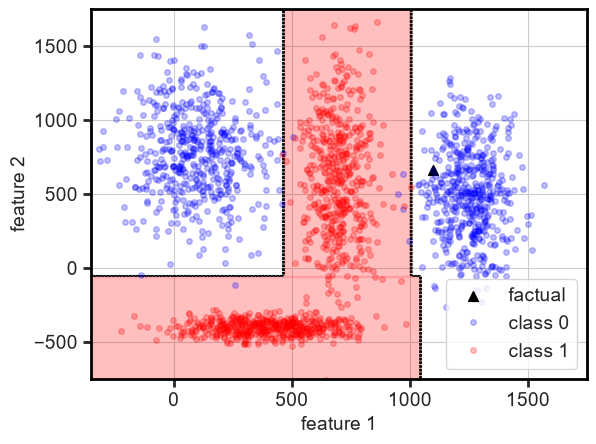

In [17]:
xx, yy = np.meshgrid(np.arange(x_min, x_max + 50, 10), np.arange(y_min, y_max + 50, 10))

Z = clf1.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.contour(xx, yy, Z, linewidths=0.5, linestyles="--", colors = "black")
plt.xlabel("feature 1")
plt.ylabel("feature 2")

plt.scatter(x_f1, x_f2, c="black", marker="^", zorder=1, s = 50, label = "factual", rasterized=True)

# RULE 1
#Rule satisfied by CE: IF CE.feature2<= -55.5,CE.feature1<=1043.5 THEN class 1 [0.9974]

delta_x = abs(x_min - 1043.5) 
delta_y = abs(y_min - -119.-55.5)

rect = plt.Rectangle((x_min, y_min), delta_x, delta_y, fill = True, alpha = 0.25, color = "red")
plt.gca().add_patch(rect)

# RULE 3
#Rule satisfied by CE: IF CE.feature2> -55.5,CE.feature1>466.0,CE.feature1<=1004.0 THEN class 1 [0.9939]


delta_x = abs(1004 - 466)
delta_y = abs(x_max - -55.5)
x = 466
y = -55.5

rect = plt.Rectangle((x, y), delta_x, delta_y, fill = True, alpha = 0.25, color = "red")
plt.gca().add_patch(rect)

colour_index = 0
for name, group in groups:
    plt.plot(group.feature1, group.feature2, marker='o', linestyle='', markersize=4, label=name, alpha=0.25, color = colours[colour_index], rasterized=True)
    colour_index=+1

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.legend(frameon=True)
#plt.title("admissible contrastive regions (rules)")

plt.savefig(plots+"contrastive_region.pdf", bbox_inches='tight', dpi=400)
plt.show()

In [18]:
# relating F and CE - with solutions
r.constraint("CE.feature2 = F.feature2") # keep feature 2 constant > only one admissible region for CE
r.solveopt()

---
Answer constraint: F.feature1=1100.0,F.feature2=661.0,CE.feature2=661.0,CE.feature1>466.0,CE.feature1<=1004.0
Rule satisfied by F: IF F.feature2> -55.5,F.feature1>1004.0 THEN class 0 [1.0000, 0.2493]
Rule satisfied by CE: IF CE.feature2> -55.5,CE.feature1>466.0,CE.feature1<=1004.0 THEN class 1 [0.9939, 0.2329]


In [19]:
# programmatic access to factual rules, their confidence, and coverage
r.rules("F")

[('F.feature2> -55.5,F.feature1>1004.0', 1.0, 0.24928571428571428)]

In [20]:
# contrastive rule
r.solveopt(project=['CE'])

---
Answer constraint: CE.feature2=661.0,CE.feature1>466.0,CE.feature1<=1004.0
Contrastive rule satisfied by CE: IF Answer constraint THEN class 1 [1.0000]
Rule satisfied by CE: IF CE.feature1>466.0,CE.feature1<=1004.0,CE.feature2> -55.5 THEN class 1 [0.9939, 0.2329]


D:\Prog\anaconda3\envs\poc_cf\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


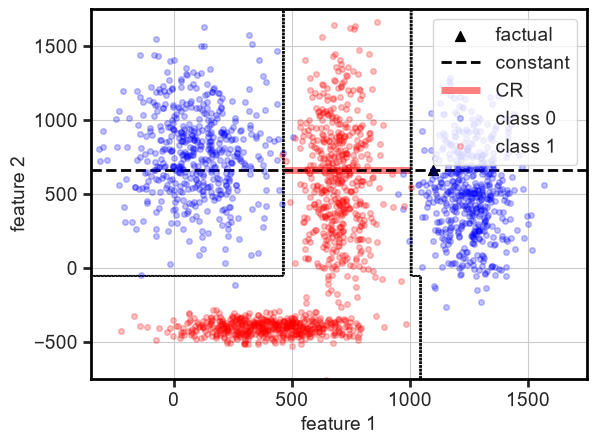

In [21]:
xx, yy = np.meshgrid(np.arange(x_min, x_max + 50, 10), np.arange(y_min, y_max + 50, 10))

Z = clf1.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

#plt.subplot(1, 2, 1)

plt.contour(xx, yy, Z, linewidths=0.5, linestyles="--", colors = "black")
plt.xlabel("feature 1")
plt.ylabel("feature 2")

plt.scatter(x_f1, x_f2, c="black", marker="^", zorder=1, s = 50, label = "factual", rasterized=True)

plt.hlines(x_f2, x_min, x_max, color = "black", label = "constant", linestyles="--")

#Answer constraint: F.feature1=1100.0,F.feature2=661.0,CE.feature2=661.0,CE.feature1>466.0,CE.feature1<=1004.0

f_feature1_upper = 1004
f_feature1_lower = 466
plt.hlines(661.0, f_feature1_lower, f_feature1_upper, colors="red", zorder = 1, linewidth = 5, alpha = 0.5, label = "CR")

colour_index = 0
for name, group in groups:
    plt.plot(group.feature1, group.feature2, marker='o', linestyle='', markersize=4, label=name, alpha=0.25, color = colours[colour_index], rasterized=True)
    colour_index=+1

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
#plt.title("admissible contrastive regions (rules), condition 1")
plt.legend(frameon=True)

plt.savefig(plots+"contrastive_regions_condition1.pdf", bbox_inches='tight', dpi=400)
plt.show()

In [22]:
# minimal contrastive rule
r.solveopt(minimize='l1norm(F, CE)', project=['CE'])

---
Answer constraint: CE.feature1=1003.9999999999999,CE.feature2=661.0
Contrastive rule satisfied by CE: IF Answer constraint THEN class 1 [1.0000]
Min value:0.0510
Rule satisfied by CE: IF CE.feature1>466.0,CE.feature1<=1004.0,CE.feature2> -55.5 THEN class 1 [0.9939, 0.2329]


In [23]:
assert r.answers() == ['CE.feature1=1003.9999999999999,CE.feature2=661.0']

D:\Prog\anaconda3\envs\poc_cf\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


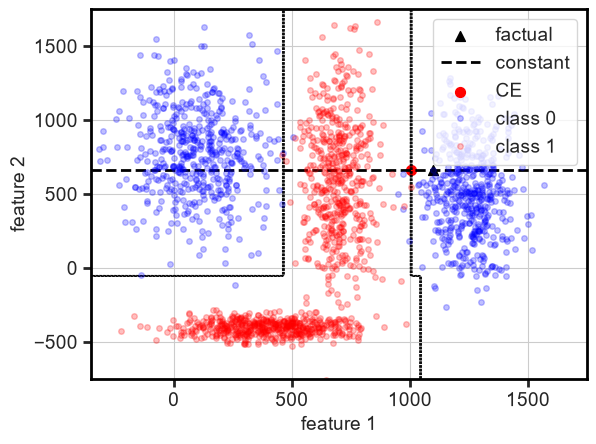

In [24]:
xx, yy = np.meshgrid(np.arange(x_min, x_max + 50, 10), np.arange(y_min, y_max + 50, 10))

Z = clf1.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

#plt.subplot(1, 2, 1)

plt.contour(xx, yy, Z, linewidths=0.5, linestyles="--", colors = "black")
plt.xlabel("feature 1")
plt.ylabel("feature 2")

plt.scatter(x_f1, x_f2, c="black", marker="^", zorder=1, s = 50, label = "factual", rasterized=True)

plt.hlines(x_f2, x_min, x_max, color = "black", label = "constant", linestyles="--")

# RESULTS
# CF.feature1=1003.9999999999999,CF.feature2=661.0

cf_feature1=1003.9999999999999
cf_feature2=661.0

plt.scatter(cf_feature1, cf_feature2, c="red", marker="o", zorder=1, s = 50, label = "CE", rasterized=True)

colour_index = 0
for name, group in groups:
    plt.plot(group.feature1, group.feature2, marker='o', linestyle='', markersize=4, label=name, alpha=0.25, color = colours[colour_index])
    colour_index=+1

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
#plt.title("closest CE, condition 3")
plt.legend(frameon=True)

#plt.savefig("contrastive_regions_condition3.pdf", bbox_inches='tight', dpi=400)

In [25]:
# relating F and CE - without solutions
r.retract("CE.feature2 = F.feature2") 
r.constraint("CE.feature1 = F.feature1") # keep feature 1 constant > no admissible region for CE
r.solveopt()

1 constraint(s) retracted
No answer.


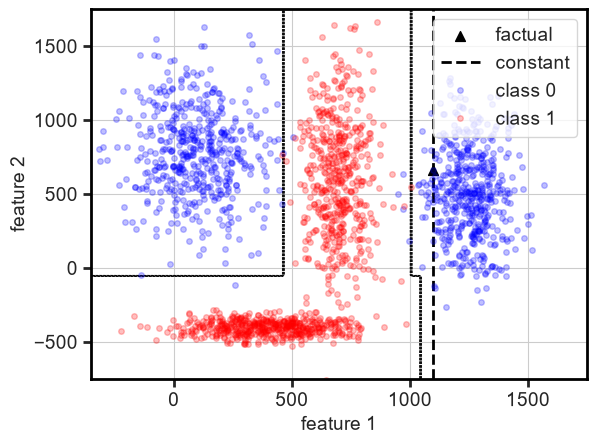

In [26]:
plt.contour(xx, yy, Z, linewidths=0.5, linestyles="--", colors = "black")
plt.xlabel("feature 1")
plt.ylabel("feature 2")

plt.scatter(x_f1, x_f2, c="black", marker="^", zorder=1, s = 50, label = "factual", rasterized=True)

plt.vlines(x_f1, y_min, y_max, color = "black", label = "constant", linestyles="--")

colour_index = 0
for name, group in groups:
    plt.plot(group.feature1, group.feature2, marker='o', linestyle='', markersize=4, label=name, alpha=0.25, color = colours[colour_index], rasterized=True)
    colour_index=+1

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
#plt.title("admissible contrastive regions (rules), condition 2")
plt.legend(frameon=True)

plt.savefig(plots+"contrastive_regions_condition2.pdf", bbox_inches='tight', dpi=400)
plt.show()

In [27]:
# minimal contrastive rule over the identity line
r.verbosity(2)
r.retract(last=True)
r.constraint("CE.feature2 = CE.feature1")
r.solveopt(minimize="l1norm(F, CE)", project=['CE'])

1 constraint(s) retracted
---
Answer constraint: CE.feature1= -55.5,CE.feature2= -55.5
Contrastive rule satisfied by CE: IF Answer constraint THEN class 1 [1.0000]
Min value:0.8937
Rule satisfied by CE: IF CE.feature1<=1043.5,CE.feature2<= -55.5 THEN class 1 [0.9974, 0.2707]
---
Answer constraint: CE.feature1=1004.0,CE.feature2=1004.0
Contrastive rule satisfied by CE: IF Answer constraint THEN class 1 [1.0000]
Min value:0.1849
Rule satisfied by CE: IF CE.feature1>466.0,CE.feature1<=1004.0,CE.feature2> -55.5 THEN class 1 [0.9939, 0.2329]


In [28]:
if assertion_check:
    assert r.answers() == ['CE.feature1= -55.5,CE.feature2= -55.5','CE.feature1=1004.0,CE.feature2=1004.0']

In [29]:
# contrastive rule fidelities
r.fidelities()

[1, 1]

In [30]:
# minimal distances
r.minvalues()

[0.8937480211842728, 0.1849416220832308]

In [31]:
# factual constraint and prob
r.rules("CE")

[('CE.feature1<=1043.5,CE.feature2<= -55.5',
  0.9973614775725593,
  0.27071428571428574),
 ('CE.feature1>466.0,CE.feature1<=1004.0,CE.feature2> -55.5',
  0.9938650306748467,
  0.23285714285714285)]

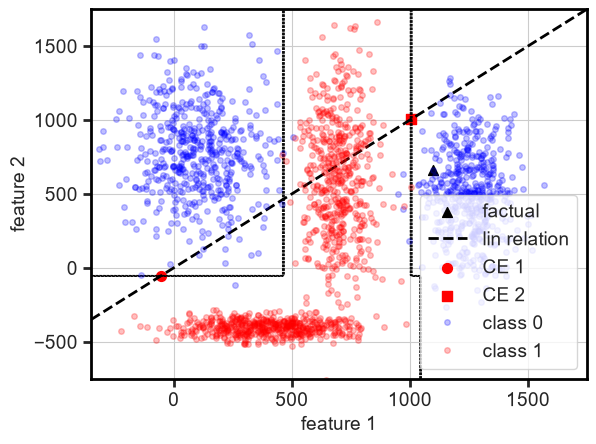

In [32]:
plt.contour(xx, yy, Z, linewidths=0.5, linestyles="--", colors = "black")
plt.xlabel("feature 1")
plt.ylabel("feature 2")

plt.scatter(x_f1, x_f2, c="black", marker="^", zorder=1, s = 50, label = "factual", rasterized=True)

x_linear = np.linspace(x_min, x_max, 50)
y_linear = x_linear

plt.plot(x_linear, y_linear, color = "black", label = "lin relation", linestyle = "dashed")

# RESULTS
# Answer constraint: F.feature1=1100.0,F.feature2=661.0,CE.feature1= -55.5,CE.feature2= -55.5

cf_feature1= -55.5
cf_feature2= -55.5

plt.scatter(cf_feature1, cf_feature2, c="red", marker="o", zorder=1, s = 50, label = "CE 1", rasterized=True)

# Answer constraint: F.feature1=1100.0,F.feature2=661.0,CE.feature1=1004.0,CE.feature2=1004.0

cf_feature1=1004.0
cf_feature2=1004.0

plt.scatter(cf_feature1, cf_feature2, c="red", marker="s", zorder=1, s = 50, label = "CE 2", rasterized=True)

colour_index = 0
for name, group in groups:
    plt.plot(group.feature1, group.feature2, marker='o', linestyle='', markersize=4, label=name, alpha=0.25, color = colours[colour_index], rasterized=True)
    colour_index=+1

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
#plt.title("closest CE, condition 4")
plt.legend(frameon=True)

plt.savefig(plots+"contrastive_regions_condition4.pdf", bbox_inches='tight', dpi=400)
plt.show()

In [33]:
# display contrastive rule and fidelity (must be 1 because DT = black-box)
r.solveopt(minimize="l1norm(F, CE)", project=["CE"])

---
Answer constraint: CE.feature1= -55.5,CE.feature2= -55.5
Contrastive rule satisfied by CE: IF Answer constraint THEN class 1 [1.0000]
Min value:0.8937
Rule satisfied by CE: IF CE.feature1<=1043.5,CE.feature2<= -55.5 THEN class 1 [0.9974, 0.2707]
---
Answer constraint: CE.feature1=1004.0,CE.feature2=1004.0
Contrastive rule satisfied by CE: IF Answer constraint THEN class 1 [1.0000]
Min value:0.1849
Rule satisfied by CE: IF CE.feature1>466.0,CE.feature1<=1004.0,CE.feature2> -55.5 THEN class 1 [0.9939, 0.2329]


In [34]:
r.reset(keep_model=True)
f_feature1 = x_f1
f_feature2 = x_f2
r.instance("F", label=y1.iloc[0])
r.constraint("F.feature1 = " + str(f_feature1))
r.constraint("F.feature2 >= " + str(f_feature2 - 500))
r.constraint("F.feature2 <= " + str(f_feature2 + 500))
r.instance("CE", label=1-y1.iloc[0], minconf=0.8)
r.solveopt(minimize="l1norm(F, CE)", project=["CE"])
# CE.feature1=1003.9999999999999 seems a rounding error in the minimization problem, it should be CE.feature1=1004.0

---
Answer constraint: CE.feature1=1043.5,CE.feature2= -55.5
Contrastive rule satisfied by CE: IF Answer constraint THEN class 1 [1.0000]
Min value:0.1146
Rule satisfied by CE: IF CE.feature1<=1043.5,CE.feature2<= -55.5 THEN class 1 [0.9974, 0.2707]
---
Answer constraint: CE.feature1=1003.9999999999999,CE.feature2>=161.0,CE.feature2<=1161.0
Contrastive rule satisfied by CE: IF Answer constraint THEN class 1 [1.0000]
Min value:0.0510
Rule satisfied by CE: IF CE.feature1>466.0,CE.feature1<=1004.0,CE.feature2> -55.5 THEN class 1 [0.9939, 0.2329]


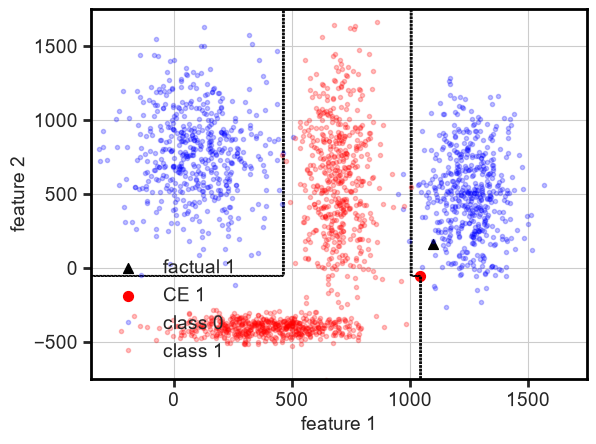

In [35]:
plt.contour(xx, yy, Z, linewidths=0.5, linestyles="--", colors = "black")
plt.xlabel("feature 1")
plt.ylabel("feature 2")

# RESULTS PART 2
# Answer constraint: CE.feature1=1043.5,CE.feature2= -55.5

plt.scatter(1100.0, 161.0, c="black", marker="^", zorder=1, s = 50, label = "factual 1", rasterized=True)
plt.scatter(1043.5, -55.5, c="red", marker="o", zorder=1, s = 50, label = "CE 1", rasterized=True)

colour_index = 0
for name, group in groups:
    plt.plot(group.feature1, group.feature2, marker='o', linestyle='', markersize=3, label=name, alpha=0.25, color = colours[colour_index])
    colour_index=+1

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
#plt.title("closest CE, condition 5")
plt.legend(loc = "lower left")

#plt.savefig(plots+"contrastive_regions_condition5_2.pdf", bbox_inches='tight', dpi=400)
plt.show()

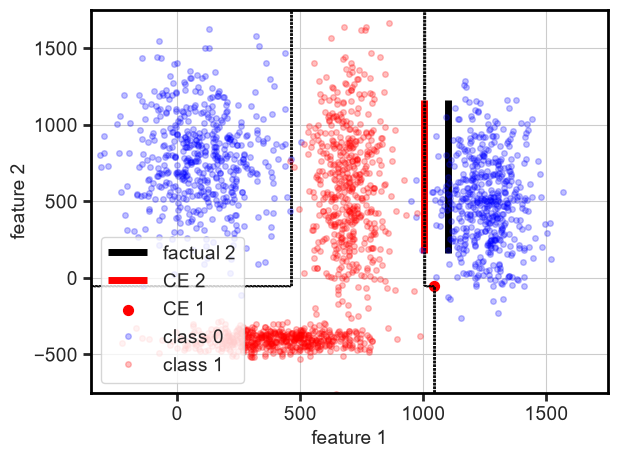

In [36]:
plt.contour(xx, yy, Z, linewidths=0.5, linestyles="--", colors = "black")
plt.xlabel("feature 1")
plt.ylabel("feature 2")

# RESULTS PART 3
plt.vlines(x_f1, f_feature2 - 500, f_feature2 + 500, colors="black", zorder = 1, label = "factual 2", linewidth = 5)

#Answer constraint: CE.feature1=1003.9999999999999,CE.feature2>=161.0,CE.feature2<=1161.0

plt.vlines(1003.9999999999999, f_feature2 - 500, f_feature2 + 500, colors="red", zorder = 1, label = "CE 2", linewidth = 5)

# ADD FIRST ANSWER
plt.scatter(1043.5, -55.5, c="red", marker="o", zorder=1, s = 50, label = "CE 1", rasterized=True)

colour_index = 0
for name, group in groups:
    plt.plot(group.feature1, group.feature2, marker='o', linestyle='', markersize=4, label=name, alpha=0.25, color = colours[colour_index], rasterized=True)
    colour_index=+1

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
#plt.title("closest CE, condition 5")
plt.legend(frameon=True, loc = "lower left")
plt.tight_layout()

plt.savefig(plots+"contrastive_regions_condition5.pdf", bbox_inches='tight', dpi=400)
plt.show()